# TARDIS — Modèle de prédiction des retards

**Target :** `Average delay of all trains at arrival` (régression, minutes)  
**Pipeline :** Linear Regression → Random Forest → XGBoost + tuning  
**Split :** chronologique — train 2018-2022 / test 2023-2024

## 1. Imports & configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import xgboost as xgb
import joblib

SEED = 42
TARGET = 'Average delay of all trains at arrival'
print('Imports OK')

Imports OK


## 2. Chargement & filtre temporel

In [2]:
df = pd.read_csv('cleaned_dataset.csv', parse_dates=['Date'])
print('Shape brut :', df.shape)

# Filtre : garder uniquement les années cohérentes avec le dataset SNCF
YEAR_MIN, YEAR_MAX = 2018, 2024
df = df[df['Date'].dt.year.between(YEAR_MIN, YEAR_MAX)].reset_index(drop=True)
print(f'Shape après filtre {YEAR_MIN}-{YEAR_MAX} :', df.shape)
print('Distribution par année :')
print(df['Date'].dt.year.value_counts().sort_index())

Shape brut : (10662, 34)
Shape après filtre 2018-2024 : (9829, 34)
Distribution par année :
Date
2018    1471
2019    1401
2020    1430
2021    1400
2022    1378
2023    1376
2024    1373
Name: count, dtype: int64


## 3. Sélection des features

On encode les stations (LabelEncoder) et on exclut les colonnes qui **reconstruiraient directement la target** (leakage) ou sont redondantes.

In [3]:
# Encodage label des stations (59 gares uniques chacune)
for col in ['Departure station', 'Arrival station']:
    le = LabelEncoder()
    mask = df[col].notna()
    df.loc[mask, col + '_enc'] = le.fit_transform(df.loc[mask, col])

FEATURES = [
    # Identité de la route
    'Departure station_enc', 'Arrival station_enc',
    'Service_encoded',
    # Temporel
    'year', 'month', 'quarter', 'month_sin', 'month_cos',
    # Volume trafic
    'Number of scheduled trains',
    # Taux calculés (feature engineering S1)
    'cancel_rate', 'delay_rate_departure', 'severe_delay_rate',
    # Retard au départ (précède l'arrivée — pas de leakage)
    'Average delay of all trains at departure',
    'Average delay of late trains at departure',
    # Causes de retard (%)
    'Pct delay due to external causes',
    'Pct delay due to infrastructure',
    'Pct delay due to traffic management',
    'Pct delay due to rolling stock',
    'Pct delay due to station management and equipment reuse',
    'Pct delay due to passenger handling (crowding, disabled persons, connections)',
]

# Garder uniquement les features présentes dans le df
FEATURES = [f for f in FEATURES if f in df.columns]
print(f'{len(FEATURES)} features retenues :')
for f in FEATURES:
    print(f'  {f}')

20 features retenues :
  Departure station_enc
  Arrival station_enc
  Service_encoded
  year
  month
  quarter
  month_sin
  month_cos
  Number of scheduled trains
  cancel_rate
  delay_rate_departure
  severe_delay_rate
  Average delay of all trains at departure
  Average delay of late trains at departure
  Pct delay due to external causes
  Pct delay due to infrastructure
  Pct delay due to traffic management
  Pct delay due to rolling stock
  Pct delay due to station management and equipment reuse
  Pct delay due to passenger handling (crowding, disabled persons, connections)


## 4. Split chronologique

Train : 2018-2022 | Test : 2023-2024  
On split **par date** et non aléatoirement pour éviter le data leakage temporel.

In [4]:
SPLIT_DATE = '2023-01-01'

df_model = df[df[TARGET].notna()].copy()

train = df_model[df_model['Date'] < SPLIT_DATE]
test  = df_model[df_model['Date'] >= SPLIT_DATE]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f'Train : {len(train)} lignes ({train["Date"].dt.year.min()}-{train["Date"].dt.year.max()})')
print(f'Test  : {len(test)} lignes ({test["Date"].dt.year.min()}-{test["Date"].dt.year.max()})')
print(f'\nTarget — train : mean={y_train.mean():.2f}  std={y_train.std():.2f}')
print(f'Target — test  : mean={y_test.mean():.2f}  std={y_test.std():.2f}')

Train : 6543 lignes (2018-2022)
Test  : 2546 lignes (2023-2024)

Target — train : mean=8.26  std=13.19
Target — test  : mean=9.35  std=12.24


## 5. Pipeline d'évaluation

In [5]:
results = {}

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    """Fit, predict, store & print metrics."""
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae  = mean_absolute_error(y_te, preds)
    rmse = root_mean_squared_error(y_te, preds)
    r2   = r2_score(y_te, preds)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'model': model}
    print(f'{name:<30}  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}')
    return preds

# Imputer partagé (médiane) — on fit sur train uniquement
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)
print('Imputation OK')

Imputation OK


## 6. Baseline — Régression linéaire (Ridge)

In [6]:
# Ridge = LinearRegression avec régularisation L2 (plus stable que OLS pur)
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=1.0))
])

evaluate('Ridge', ridge_pipe,
         X_train_imp, y_train,
         X_test_imp,  y_test)

Ridge                           MAE=5.586  RMSE=12.310  R²=-0.012


array([ 6.87375848,  7.58417113, 10.80099276, ...,  6.35181474,
        6.88031796,  7.61740474], shape=(2546,))

## 7. Random Forest

In [7]:
rf_base = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1
)
evaluate('RandomForest (base)', rf_base,
         X_train_imp, y_train,
         X_test_imp,  y_test)

RandomForest (base)             MAE=5.998  RMSE=12.171  R²=0.011


array([ 6.55495999, 10.99623756, 11.88774638, ...,  9.9242046 ,
       12.09481342,  8.07239265], shape=(2546,))

## 8. XGBoost

In [8]:
xgb_base = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbosity=0
)
evaluate('XGBoost (base)', xgb_base,
         X_train_imp, y_train,
         X_test_imp,  y_test)

XGBoost (base)                  MAE=5.951  RMSE=12.184  R²=0.009


array([ 0.22600368,  7.297227  , 13.360458  , ..., 13.507345  ,
        9.946808  ,  9.676987  ], shape=(2546,), dtype=float32)

## 9. Tuning — RandomizedSearchCV

On tune Random Forest et XGBoost séparément, puis on compare.

In [9]:
rf_param_grid = {
    'n_estimators':    [200, 400, 600],
    'max_depth':       [None, 10, 20, 30],
    'min_samples_leaf':[1, 2, 5],
    'max_features':    ['sqrt', 'log2', 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    rf_param_grid,
    n_iter=20,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train_imp, y_train)
print('Meilleurs params RF :', rf_search.best_params_)
evaluate('RandomForest (tuned)', rf_search.best_estimator_,
         X_train_imp, y_train,
         X_test_imp,  y_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Meilleurs params RF : {'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 10}
RandomForest (tuned)            MAE=5.408  RMSE=12.040  R²=0.032


array([ 5.9177965 ,  8.45134502, 12.92608223, ...,  9.41886813,
       10.34804234,  7.40666947], shape=(2546,))

In [10]:
xgb_param_grid = {
    'n_estimators':     [200, 400, 600],
    'learning_rate':    [0.01, 0.05, 0.1],
    'max_depth':        [4, 6, 8],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha':        [0, 0.1, 1.0],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=SEED, verbosity=0),
    xgb_param_grid,
    n_iter=20,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train_imp, y_train)
print('Meilleurs params XGB :', xgb_search.best_params_)
evaluate('XGBoost (tuned)', xgb_search.best_estimator_,
         X_train_imp, y_train,
         X_test_imp,  y_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Meilleurs params XGB : {'subsample': 1.0, 'reg_alpha': 0.1, 'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
XGBoost (tuned)                 MAE=5.361  RMSE=12.025  R²=0.035


array([4.4133224, 8.829064 , 9.784415 , ..., 8.238313 , 9.634928 ,
       7.0276103], shape=(2546,), dtype=float32)

## 10. Comparaison des modèles

,MAE,RMSE,R²
XGBoost (tuned),5.361,12.025,0.035
RandomForest (tuned),5.408,12.040,0.032
Ridge,5.586,12.310,-0.012
XGBoost (base),5.951,12.184,0.009
RandomForest (base),5.998,12.171,0.011


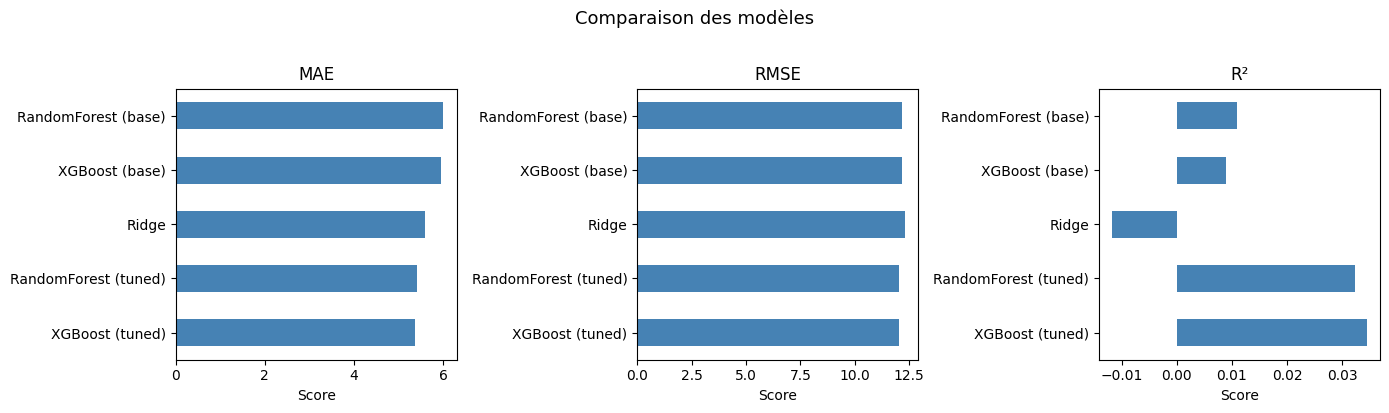

In [11]:
summary = pd.DataFrame(
    {k: {m: results[k][m] for m in ['MAE','RMSE','R²']} for k in results}
).T.sort_values('MAE')
display(summary.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    summary[metric].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(metric)
    ax.set_xlabel('Score')
plt.suptitle('Comparaison des modèles', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 11. Feature importance — meilleur modèle

Meilleur modèle : XGBoost (tuned)


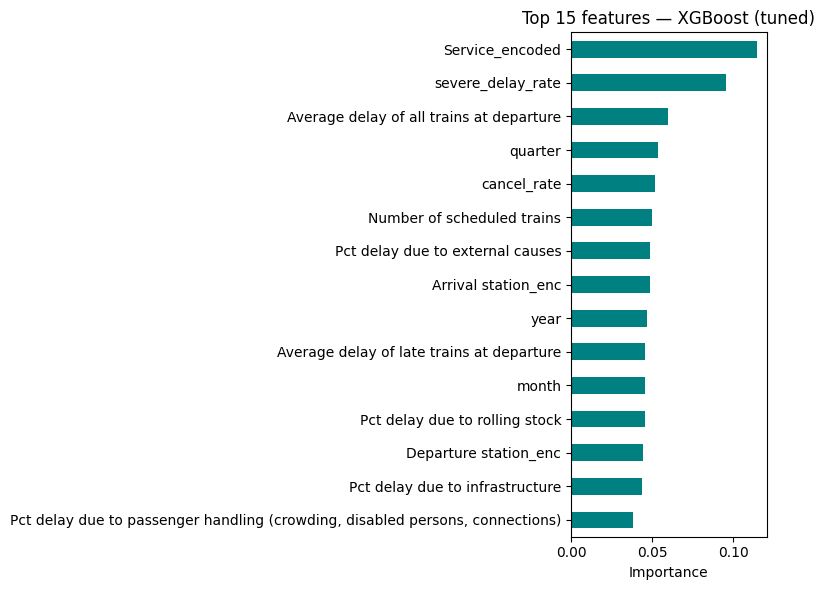

In [12]:
# Identifier le meilleur modèle (MAE minimale)
best_name = summary['MAE'].idxmin()
best_model = results[best_name]['model']
print(f'Meilleur modèle : {best_name}')

# Récupérer les importances (RF ou XGB)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'named_steps'):  # Pipeline Ridge
    importances = np.abs(best_model.named_steps['ridge'].coef_)

feat_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.head(15).sort_values().plot(kind='barh', ax=ax, color='teal')
ax.set_title(f'Top 15 features — {best_name}')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 12. Analyse des résidus — meilleur modèle

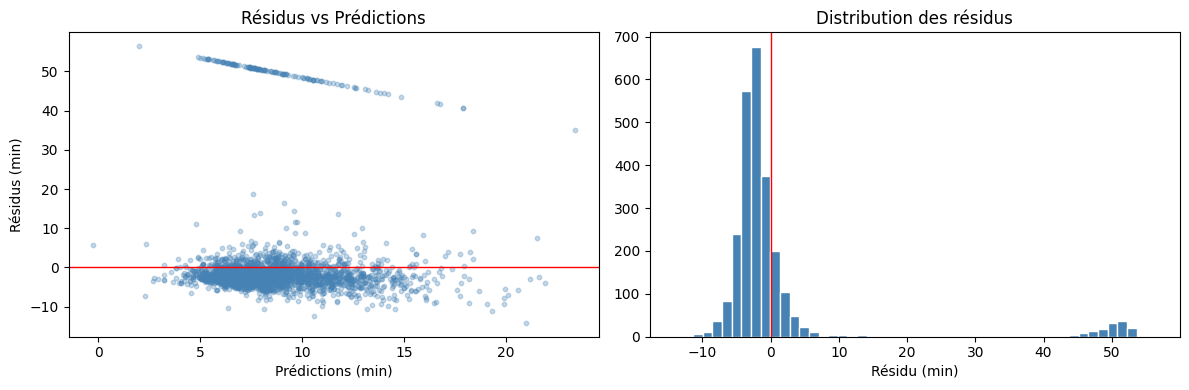

Résidu médian : -2.289 min
% résidus < ±2 min : 33.3%


In [13]:
best_preds = best_model.predict(X_test_imp)
residuals  = y_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Résidus vs prédictions
axes[0].scatter(best_preds, residuals, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='red', lw=1)
axes[0].set_xlabel('Prédictions (min)')
axes[0].set_ylabel('Résidus (min)')
axes[0].set_title('Résidus vs Prédictions')

# Distribution des résidus
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', lw=1)
axes[1].set_xlabel('Résidu (min)')
axes[1].set_title('Distribution des résidus')

plt.tight_layout()
plt.show()
print(f'Résidu médian : {residuals.median():.3f} min')
print(f'% résidus < ±2 min : {(residuals.abs() < 2).mean()*100:.1f}%')

## 13. Export du modèle

In [14]:
# Sauvegarder le meilleur modèle + l'imputer (nécessaire pour le dashboard)
joblib.dump(best_model, 'model.joblib')
joblib.dump(imputer,    'imputer.joblib')
joblib.dump(FEATURES,   'features.joblib')

print(f'Modèle exporté : model.joblib ({best_name})')
print(f'Imputer exporté : imputer.joblib')
print(f'Features exportées : features.joblib ({len(FEATURES)} features)')

Modèle exporté : model.joblib (XGBoost (tuned))
Imputer exporté : imputer.joblib
Features exportées : features.joblib (20 features)


## 14. Synthèse

| Fichier | Rôle |
|---|---|
| `model.joblib` | Meilleur modèle entraîné |
| `imputer.joblib` | SimpleImputer fitté sur train |
| `features.joblib` | Liste ordonnée des features |

Ces trois fichiers sont suffisants pour faire tourner le dashboard Streamlit sans re-entraîner.